In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, MaxPooling1D, GlobalAveragePooling1D, MaxPooling2D,Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import tsfel

In [2]:
import DataLoader
path = r"C:\Users\willi\Desktop\PTBXL\\"

ecg_data, patient_data = DataLoader.loader(path)

ECG Data Shape: (21799, 1000, 12)
Patient Data Head:
        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
4          17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
5          17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   
4       1984-11-15 13:44:57              sinusrhythmus 

In [3]:
import DataLoader
patient_data = DataLoader.map_classes(patient_data)
patient_data['mapped_class'].value_counts()

mapped_class
Normal ECG                9099
Myocardial Infarction     5439
Conduction Disturbance    3134
ST/T Change               2400
Hypertrophy               1316
Other                      411
Name: count, dtype: int64

In [4]:
import pandas as pd
df = pd.DataFrame()


df['ecg_signal'] = list(ecg_data)
df['diagnosis'] = patient_data['mapped_class'].values
df['strat_fold'] = patient_data['strat_fold'].values
df['age'] = patient_data['age'].values
df = df[(df['age'] <= 100) & (df['age'] >= 18)]
df



,ecg_signal,diagnosis,strat_fold,age
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG,3,56.0
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG,2,19.0
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG,5,37.0
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG,3,24.0
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG,4,19.0
...,...,...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance,7,63.0
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change,7,67.0
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change,2,59.0
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG,8,64.0


In [5]:
df.drop(columns='age', inplace=True)
df = df[df['diagnosis'] != 'Other']
df

,ecg_signal,diagnosis,strat_fold
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG,3
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG,2
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG,5
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG,3
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG,4
...,...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance,7
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change,7
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change,2
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG,8


In [6]:
cfg = tsfel.get_features_by_domain()

features = []

for patient in df['ecg_signal']:
    signal = np.asarray(patient) 
    feat = tsfel.time_series_features_extractor(
        cfg,
        signal,
        fs=100,
        verbose=0,
        n_jobs=1
    )

    
    features.append(feat)

features_df = pd.concat(features, ignore_index=True)
features_df['diagnosis'] = df['diagnosis'].values
features_df['strat_fold'] = df['strat_fold'].values
features_df.to_csv('tsfel_features.csv', index=False)
features_df

,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,...,9_Wavelet variance_25.0Hz,9_Wavelet variance_3.12Hz,9_Wavelet variance_3.57Hz,9_Wavelet variance_4.17Hz,9_Wavelet variance_5.0Hz,9_Wavelet variance_6.25Hz,9_Wavelet variance_8.33Hz,9_Zero crossing rate,diagnosis,strat_fold
0,11.888118,0.673645,3.0,1.190002,4.600370,200.0,800.0,-0.067,0.048,0.001,...,0.007113,0.034062,0.030082,0.024544,0.019883,0.018223,0.018875,83.0,Normal ECG,3
1,17.807727,0.896710,8.0,1.782555,5.268012,200.0,800.0,-0.090,0.042,0.001,...,0.058980,0.193954,0.187828,0.170147,0.146604,0.126969,0.113726,54.0,Normal ECG,2
2,14.697014,0.718870,2.0,1.471173,4.859326,200.0,800.0,-0.070,0.028,0.001,...,0.014673,0.042151,0.042658,0.041191,0.039872,0.040410,0.040356,63.0,Normal ECG,5
3,19.000188,0.862950,3.0,1.901921,5.200815,200.0,800.0,-0.067,0.055,0.001,...,0.237195,0.703766,0.733825,0.718486,0.649799,0.585517,0.582037,51.0,Normal ECG,3
4,6.854559,0.535630,2.0,0.686142,5.057653,200.0,800.0,-0.052,0.022,0.001,...,0.034138,0.189583,0.198211,0.189430,0.166481,0.142331,0.120484,54.0,Normal ECG,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20965,6.609367,0.557765,5.0,0.661598,5.200115,200.0,800.0,-0.063,0.034,0.001,...,0.017168,0.532644,0.477652,0.425974,0.374275,0.308643,0.216230,41.0,Conduction Disturbance,7
20966,45.807704,1.227460,2.0,4.585356,4.940977,200.0,800.0,-0.128,0.055,0.001,...,0.095415,0.528918,0.482158,0.421260,0.359687,0.312093,0.277880,118.0,ST/T Change,7
20967,9.297871,0.447215,2.0,0.930718,5.280866,200.0,800.0,-0.043,0.019,0.001,...,0.018892,0.020128,0.020735,0.022307,0.025703,0.032401,0.040955,105.0,ST/T Change,2
20968,9.979229,0.549655,2.0,0.998922,4.978589,200.0,800.0,-0.052,0.021,0.001,...,0.041891,0.108827,0.099152,0.085071,0.073610,0.070993,0.075092,77.0,Normal ECG,8


In [7]:

from sklearn.tree import DecisionTreeClassifier
features_df = features_df[features_df['diagnosis'] != 'Other']
x = features_df.drop(columns=['diagnosis', 'strat_fold'])
y = features_df['diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

train_mask = features_df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = features_df['strat_fold'] == 9
test_mask = features_df['strat_fold'] == 10

x_train = x[train_mask]
x_val = x[val_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

print("Accuracy:", dt_model.score(x_test, y_test))

y_pred = dt_model.predict(x_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.5016564126833886

Classification Report:
                        precision    recall  f1-score   support

Conduction Disturbance       0.36      0.35      0.36       310
           Hypertrophy       0.26      0.25      0.25       126
 Myocardial Infarction       0.45      0.42      0.44       529
            Normal ECG       0.66      0.70      0.68       912
           ST/T Change       0.25      0.25      0.25       236

              accuracy                           0.50      2113
             macro avg       0.40      0.39      0.40      2113
          weighted avg       0.49      0.50      0.50      2113



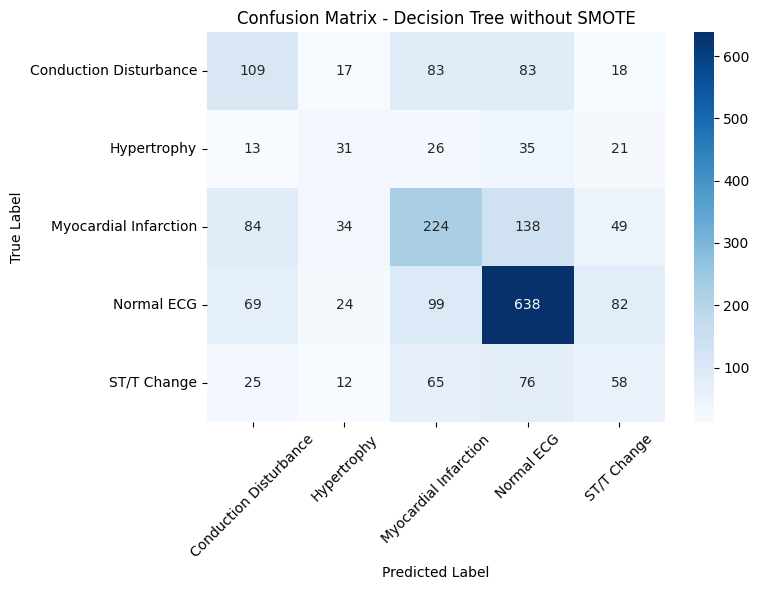

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree without SMOTE")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

features_df = features_df[features_df['diagnosis'] != 'Other']
x = features_df.drop(columns=['diagnosis', 'strat_fold'])
y = features_df['diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

train_mask = features_df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = features_df['strat_fold'] == 9
test_mask = features_df['strat_fold'] == 10

x_train = x[train_mask]
x_val = x[val_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

imputer = SimpleImputer(strategy='median')
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

smote = SMOTE(k_neighbors=3, random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_smote, y_train_smote)

print("Accuracy:", dt_model.score(x_test, y_test))
y_pred = dt_model.predict(x_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.4505442498816848

Classification Report:
                        precision    recall  f1-score   support

Conduction Disturbance       0.30      0.37      0.33       310
           Hypertrophy       0.21      0.25      0.23       126
 Myocardial Infarction       0.45      0.38      0.41       529
            Normal ECG       0.65      0.61      0.63       912
           ST/T Change       0.18      0.20      0.19       236

              accuracy                           0.45      2113
             macro avg       0.36      0.36      0.36      2113
          weighted avg       0.47      0.45      0.46      2113



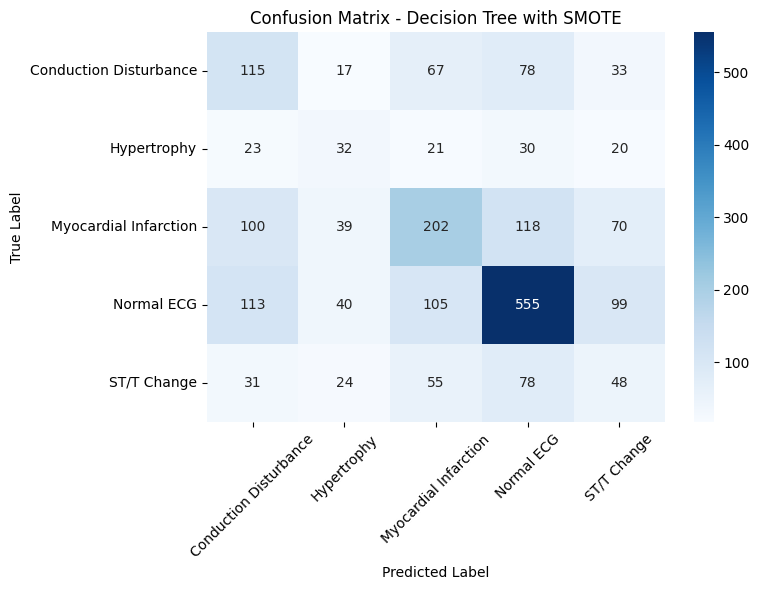

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree with SMOTE")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
!python -m pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer

features_df = features_df[features_df['diagnosis'] != 'Other']

x = features_df.drop(columns=['diagnosis', 'strat_fold'])
y = features_df['diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

train_mask = features_df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = features_df['strat_fold'] == 9
test_mask = features_df['strat_fold'] == 10

x_train = x[train_mask]
x_val = x[val_mask]
x_test = x[test_mask]

y_train = y_encoded[train_mask]
y_val = y_encoded[val_mask]
y_test = y_encoded[test_mask]

imputer = SimpleImputer(strategy='median')
x_train = imputer.fit_transform(x_train)
x_val = imputer.transform(x_val)
x_test = imputer.transform(x_test)

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(x_train, y_train)

print("Accuracy:", xgb_model.score(x_test, y_test))

y_pred = xgb_model.predict(x_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.6696639848556555

Classification Report:
                        precision    recall  f1-score   support

Conduction Disturbance       0.62      0.37      0.46       310
           Hypertrophy       0.54      0.30      0.39       126
 Myocardial Infarction       0.66      0.62      0.64       529
            Normal ECG       0.70      0.93      0.80       912
           ST/T Change       0.55      0.37      0.45       236

              accuracy                           0.67      2113
             macro avg       0.62      0.52      0.55      2113
          weighted avg       0.65      0.67      0.65      2113



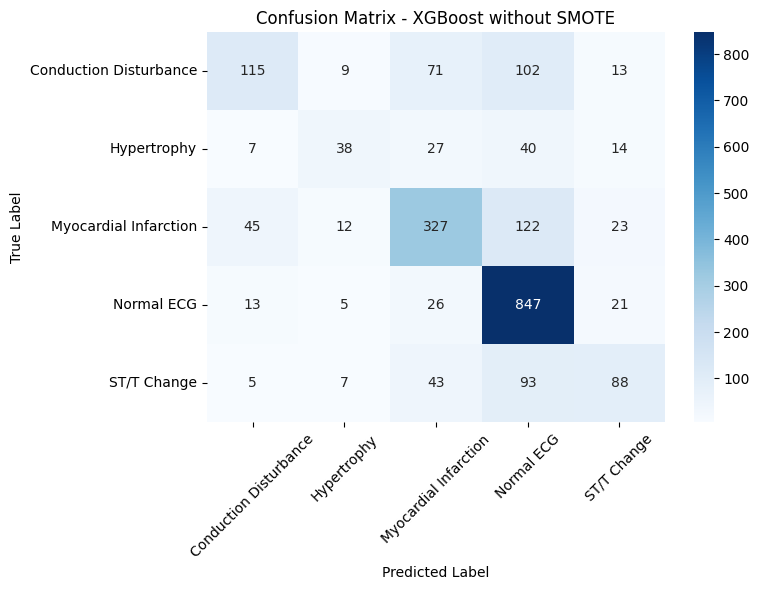

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost without SMOTE")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

features_df = features_df[features_df['diagnosis'] != 'Other']

x = features_df.drop(columns=['diagnosis', 'strat_fold'])
y = features_df['diagnosis']

le = LabelEncoder()
y = le.fit_transform(y)

train_mask = features_df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = features_df['strat_fold'] == 9
test_mask = features_df['strat_fold'] == 10

x_train = x[train_mask]
x_val = x[val_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

imputer = SimpleImputer(strategy='median')
x_train = imputer.fit_transform(x_train)
x_val = imputer.transform(x_val)
x_test = imputer.transform(x_test)

smote = SMOTE(k_neighbors=3, random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(x_train_smote, y_train_smote)

print("Accuracy:", xgb_model.score(x_test, y_test))

y_pred = xgb_model.predict(x_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.6767628963558922

Classification Report:
                        precision    recall  f1-score   support

Conduction Disturbance       0.59      0.43      0.50       310
           Hypertrophy       0.55      0.39      0.46       126
 Myocardial Infarction       0.69      0.60      0.64       529
            Normal ECG       0.72      0.90      0.80       912
           ST/T Change       0.53      0.46      0.49       236

              accuracy                           0.68      2113
             macro avg       0.62      0.56      0.58      2113
          weighted avg       0.66      0.68      0.66      2113



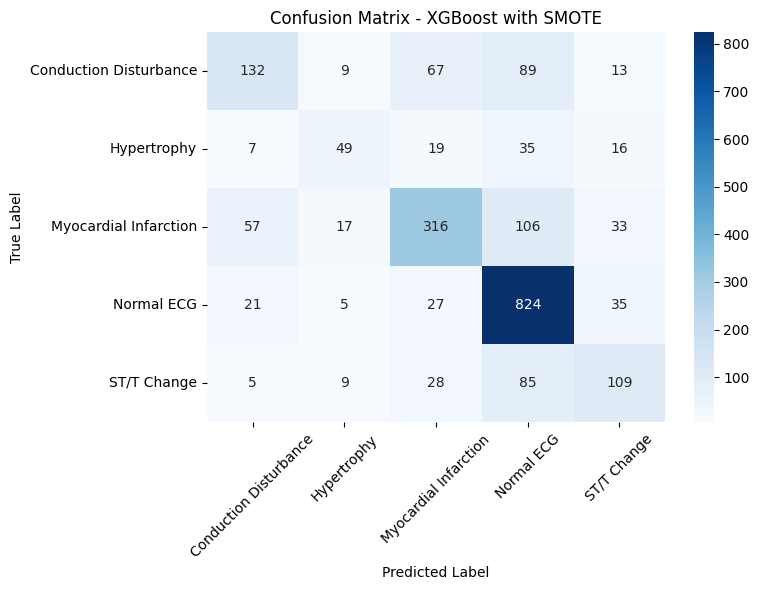

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost with SMOTE")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()